# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv("hotel-booking_raw.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## 4.1. Jumlah dan Kolom

In [3]:
df.shape

(119390, 32)

## 4.2. Tipe Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## 4.3. Jumlah Missing Value

In [5]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


## 4.4. Jumlah Kolom Duplikat

In [6]:
df.duplicated().sum()

np.int64(31994)

## 4.5. Jumlah Label

In [7]:
df["is_canceled"].value_counts()

,count
is_canceled,
0,75166
1,44224


## 4.6. Heatmap

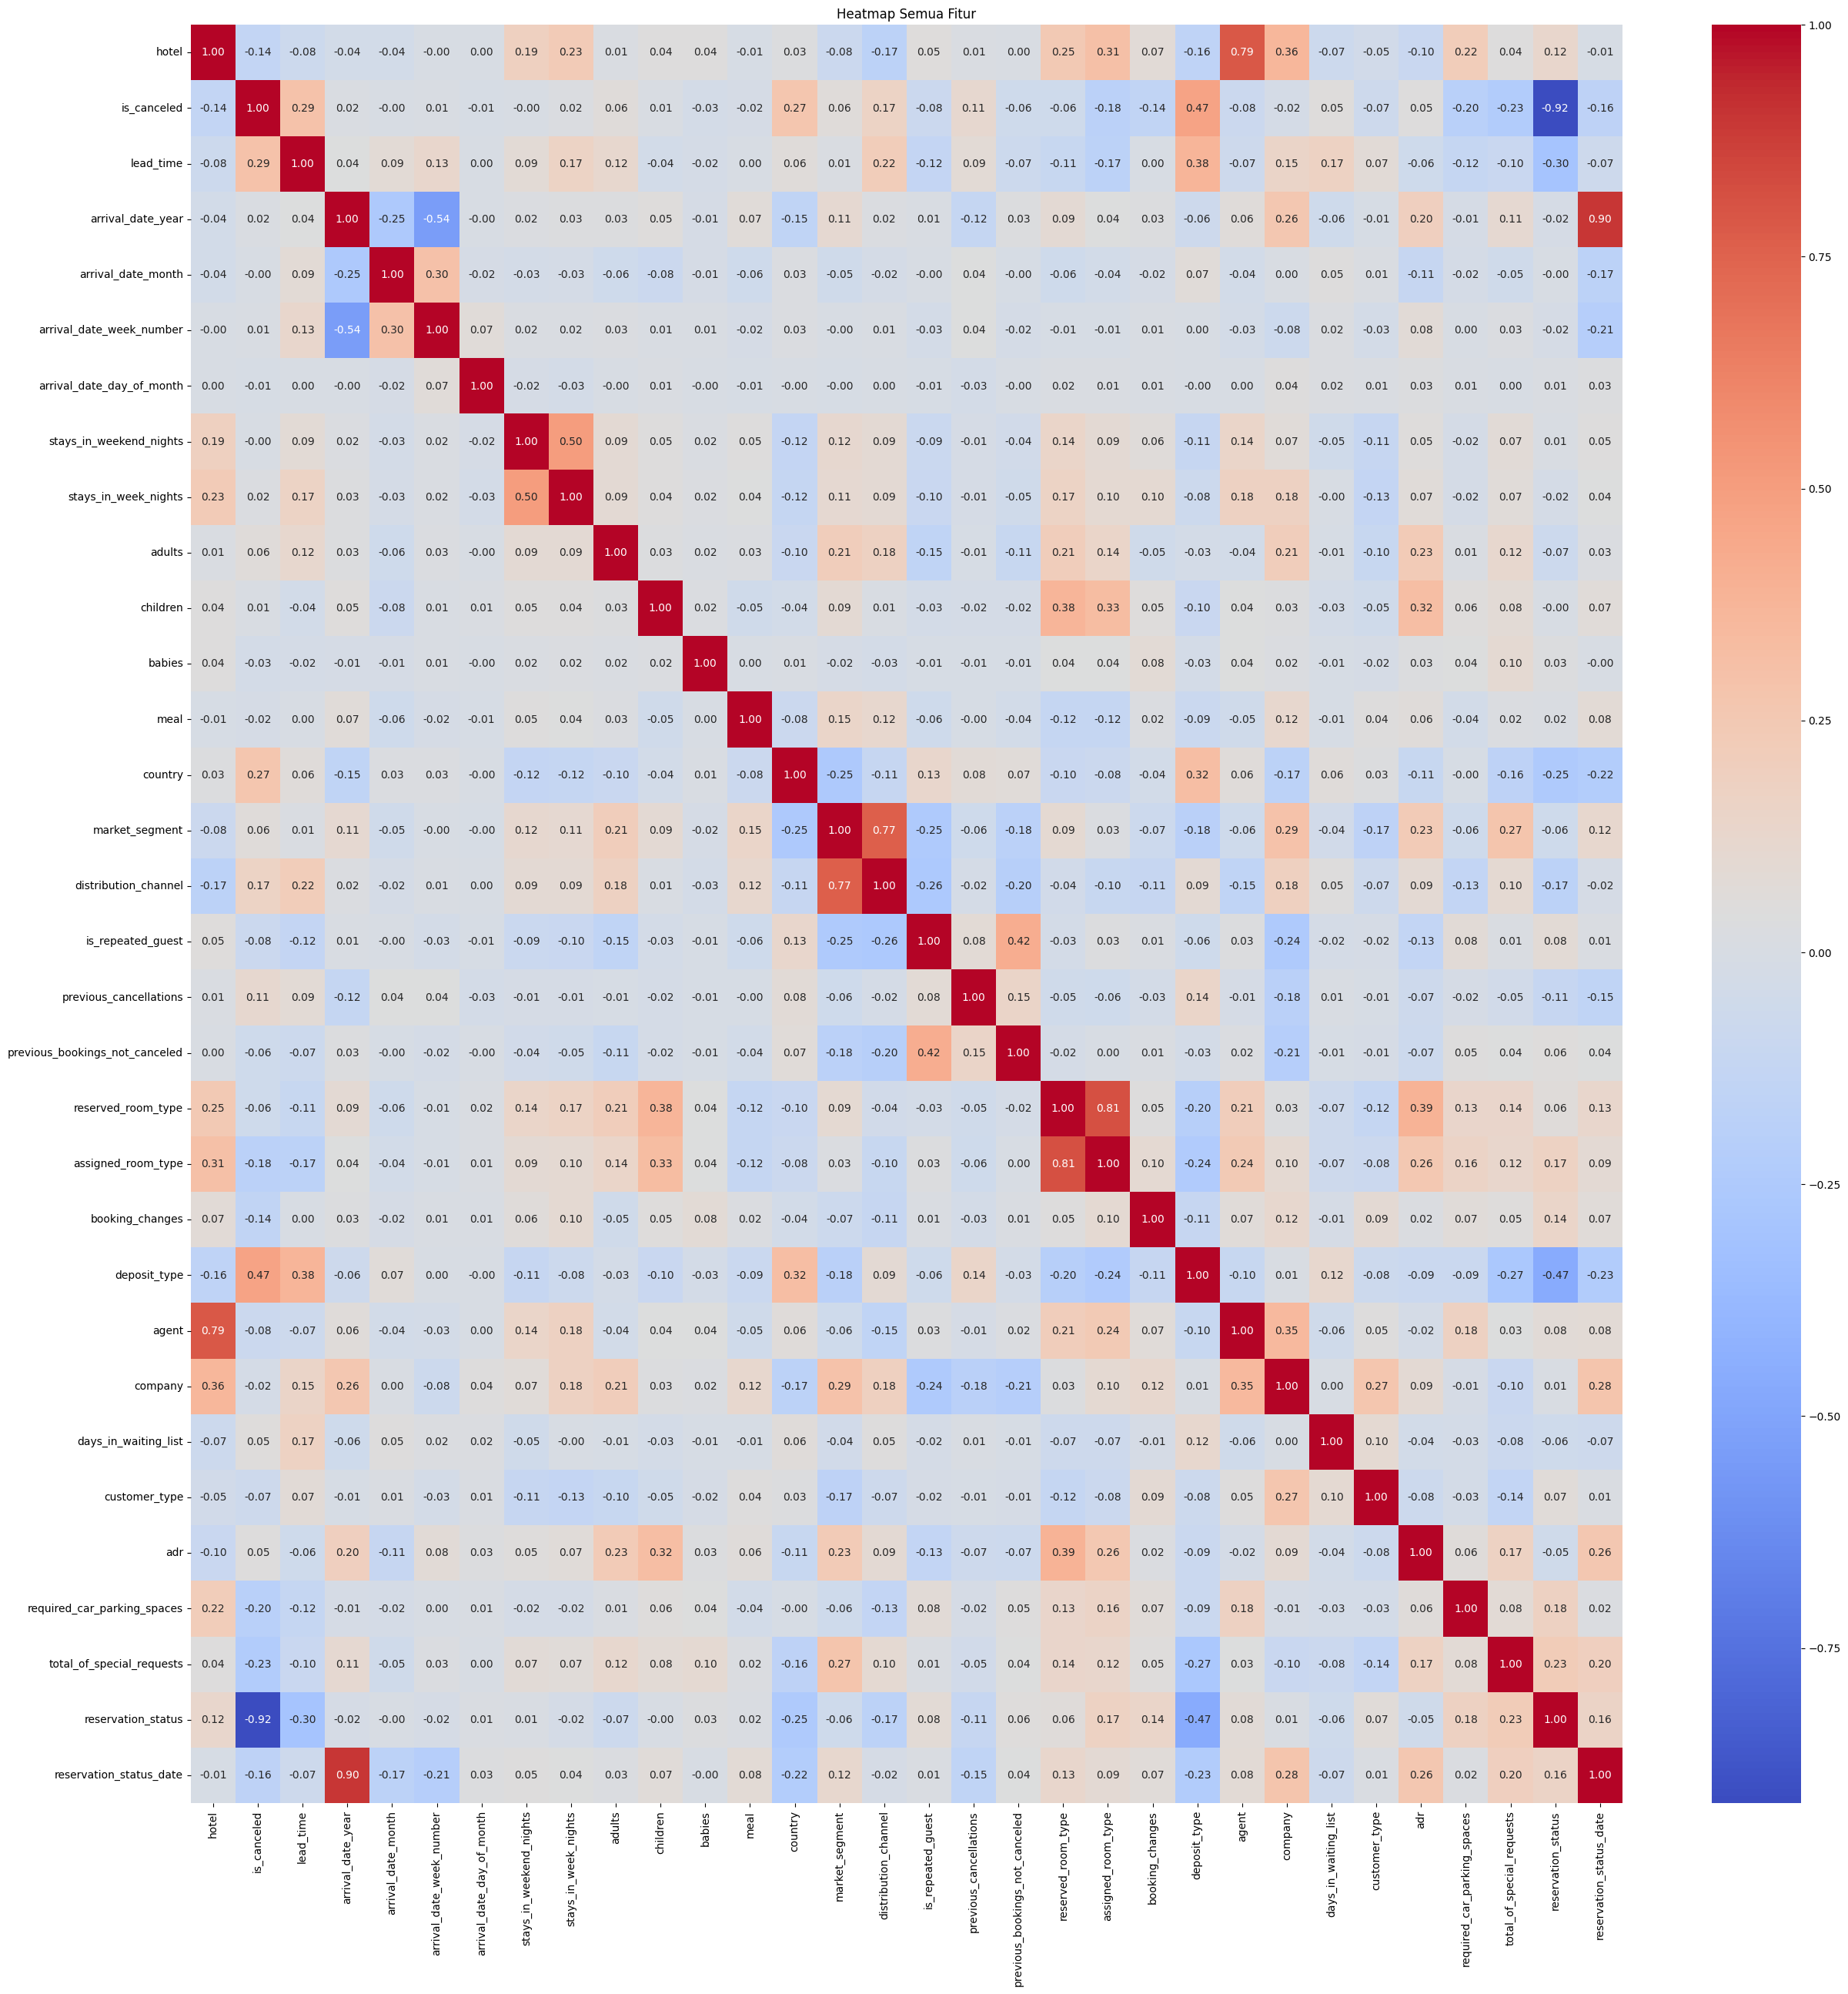

In [8]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(30, 30))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Heatmap Semua Fitur')
plt.show()

## 4.7. Fitur Kuat

In [9]:
target_correlation = df_encoded.corr()['is_canceled']

key_features = target_correlation[abs(target_correlation) > 0.15].sort_values(ascending=False)

print("Fitur yang memiliki hubungan kuat dengan target:")
print(key_features)

Fitur yang memiliki hubungan kuat dengan target:
is_canceled                    1.000000
deposit_type                   0.468634
lead_time                      0.293123
country                        0.271558
distribution_channel           0.167600
reservation_status_date       -0.162135
assigned_room_type            -0.176028
required_car_parking_spaces   -0.195498
total_of_special_requests     -0.234658
reservation_status            -0.917196
Name: is_canceled, dtype: float64


Berdasarkan Exploratory Data Analysis (EDA), dataset hotel booking ini terdiri dari **119.390 baris** dengan **32 kolom**. Tipe data yang digunakan cukup beragam, yaitu **4 kolom bertipe float**, **16 kolom bertipe integer**, dan **12 kolom bertipe object**. Analisis kualitas data menunjukkan adanya **missing value** pada beberapa kolom: **country sebanyak 488**, **agent sebanyak 16.340**, serta **company yang paling dominan dengan 112.593 nilai kosong**. **Kolom company perlu dihapus** karena proporsi missing value yang sangat besar dapat mengganggu proses pembersihan. Selain itu, ditemukan **31.994 baris duplikat** yang harus dihilangkan agar model tidak bias. Distribusi label is_canceled menunjukkan **ketidakseimbangan moderat**, dengan **75.166 data tidak dibatalkan** dan **44.224 data dibatalkan**.

Hasil analisis korelasi memperlihatkan beberapa hubungan penting. Label is_canceled memiliki korelasi kuat dengan fitur-fitur seperti deposit_type, lead_time, distribution_channel, reservation_status_date, assigned_room_type, required_car_parking_spaces, total_of_special_request. Hal ini memberikan gambaran bahwa keputusan tamu untuk membatalkan pesanan sangat dipengaruhi oleh tingkat komitmen finansial di awal (kebijakan deposit), durasi perencanaan atau seberapa jauh hari pemesanan dilakukan (lead time), serta jalur promosi yang digunakan untuk memesan (distribution channel). Selain itu, kesiapan fasilitas hotel saat hari H—seperti kesesuaian kamar yang dialokasikan, ketersediaan lahan parkir, hingga pemenuhan permintaan khusus dari tamu—menjadi indikator kuat apakah sebuah reservasi akan terealisasi atau berakhir dengan pembatalan. Ditemukan juga fitur yang membuat data leakage yaitu reservation_status sehingga fitur ini perlu dihilangkan saat pembersihan.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## 5.1. Menghapus Fitur

In [10]:
drop_cols = [
    "company",
    "agent",
    "reservation_status"
]

df.drop(
    columns=drop_cols,
    inplace=True
)

print(f"Jumlah kolom saat ini setelah menghapus fitur: {df.shape[1]} kolom")

Jumlah kolom saat ini setelah menghapus fitur: 29 kolom


## 5.2. Menghapus Missing Value

In [11]:
df.dropna(
    inplace=True
)

print(f"Jumlah baris data saat ini setelah menghapus missing value: {df.shape[0]} baris")

Jumlah baris data saat ini setelah menghapus missing value: 118898 baris


## 5.3. Menghapus Data Duplikat

In [12]:
df.drop_duplicates(inplace=True)

print(f"Jumlah baris data saat ini setelah menghapus duplikat: {df.shape[0]} baris")

Jumlah baris data saat ini setelah menghapus duplikat: 86912 baris


## 5.4. Encoding Data

In [13]:
for col in df.select_dtypes(include='object'):

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col]
    )

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,1,0,342,2015,5,27,1,0,0,2,...,2,2,3,0,0,2,0.0,0,0,121
1,1,0,737,2015,5,27,1,0,0,2,...,2,2,4,0,0,2,0.0,0,0,121
2,1,0,7,2015,5,27,1,0,1,1,...,0,2,0,0,0,2,75.0,0,0,122
3,1,0,13,2015,5,27,1,0,1,1,...,0,0,0,0,0,2,75.0,0,0,122
4,1,0,14,2015,5,27,1,0,2,2,...,0,0,0,0,0,2,98.0,0,1,123


## 5.5. Simpan Data Bersih

In [14]:
df.to_csv(
    "hotel-booking_preprocessing.csv",
    index=False
)

print(f"Data hasil preprocessing berhasil dibuat.")

Data hasil preprocessing berhasil dibuat.
